## POKEMON - G2

## TASK 1 - Data Understanding and Exploration

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("G2.csv")
df.head()

,id,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense
0,1,bulbasaur,7,69,64.0,grass,poison,45,49,49
1,2,ivysaur,10,130,142.0,grass,poison,60,62,63
2,3,venusaur,20,1000,236.0,grass,poison,80,82,83
3,4,charmander,6,85,62.0,fire,NaN,39,52,43
4,5,charmeleon,11,190,142.0,fire,NaN,58,64,58


In [5]:
df.shape

(1351, 10)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1351 entries, 0 to 1350
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1351 non-null   int64  
 1   name             1351 non-null   str    
 2   height_dm        1351 non-null   int64  
 3   weight_hg        1351 non-null   int64  
 4   base_experience  1302 non-null   float64
 5   type_1           1351 non-null   str    
 6   type_2           765 non-null    str    
 7   hp               1351 non-null   int64  
 8   attack           1351 non-null   int64  
 9   defense          1351 non-null   int64  
dtypes: float64(1), int64(6), str(3)
memory usage: 105.7 KB


In [7]:
print("Categorical_Features:", df.select_dtypes(include=['object', 'string']).columns)
print("Numerical_Features:", df.select_dtypes(include='number').columns.tolist())

Categorical_Features: Index(['name', 'type_1', 'type_2'], dtype='str')
Numerical_Features: ['id', 'height_dm', 'weight_hg', 'base_experience', 'hp', 'attack', 'defense']


In [8]:
df.duplicated().sum()

np.int64(0)

No Duplicates were found

In [9]:
df.isnull().sum()

id                   0
name                 0
height_dm            0
weight_hg            0
base_experience     49
type_1               0
type_2             586
hp                   0
attack               0
defense              0
dtype: int64

There are missing values in base_experience and type_2 features

In [10]:
df.describe()

,id,height_dm,weight_hg,base_experience,hp,attack,defense
count,1351.000000,1351.000000,1351.000000,1302.000000,1351.000000,1351.000000,1351.000000
mean,2841.692080,20.443375,991.059956,161.943932,71.673575,82.757957,76.193930
std,4139.019112,53.238467,1953.115812,82.532554,26.827529,32.351906,30.712902
min,1.000000,1.000000,0.000000,36.000000,1.000000,5.000000,5.000000
25%,338.500000,6.000000,94.500000,71.000000,55.000000,60.000000,55.000000
50%,676.000000,11.000000,326.000000,165.000000,70.000000,80.000000,70.000000
75%,1013.500000,17.000000,853.500000,222.500000,85.000000,102.500000,95.000000
max,10326.000000,1000.000000,10000.000000,608.000000,255.000000,190.000000,250.000000


In [11]:
summary_stats = df.describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
id,1351.0,2841.692080,4139.019112,1.0,338.5,676.0,1013.5,10326.0
height_dm,1351.0,20.443375,53.238467,1.0,6.0,11.0,17.0,1000.0
weight_hg,1351.0,991.059956,1953.115812,0.0,94.5,326.0,853.5,10000.0
base_experience,1302.0,161.943932,82.532554,36.0,71.0,165.0,222.5,608.0
hp,1351.0,71.673575,26.827529,1.0,55.0,70.0,85.0,255.0
attack,1351.0,82.757957,32.351906,5.0,60.0,80.0,102.5,190.0
defense,1351.0,76.193930,30.712902,5.0,55.0,70.0,95.0,250.0


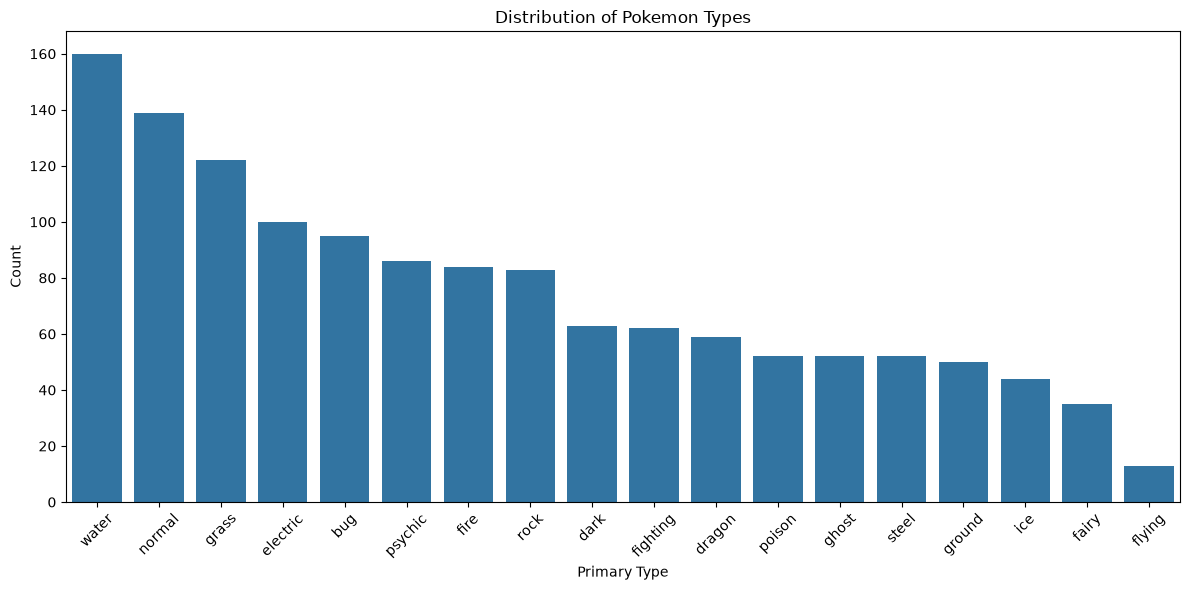

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='type_1', order=df['type_1'].value_counts().index)
plt.title('Distribution of Pokemon Types')
plt.xlabel('Primary Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


1) The Most Frequent Primary Type is: "Water" with 160 pokemon

2) The feature with the largest variation is: weight_hg because it has the highest standard deviation.Id also have std high, but it is ignored because its an identifier not a feature.

3) The dataset contains both numerical and categorical variables, with type_1 and type_2 as type labels, an uneven distrbution of Pokémon types are dominated by water, normal and grass andmix of physical and combat features which is useful for predicting the primary type using a classification model.

## TASK 2 - Data Preprocessing

In [13]:
df.isnull().sum()

id                   0
name                 0
height_dm            0
weight_hg            0
base_experience     49
type_1               0
type_2             586
hp                   0
attack               0
defense              0
dtype: int64

In [14]:
Y = df['type_1']
X = df.drop(columns=['id', 'name', 'type_1'])

Selected type_1 feature as Target.
id,name are removed because both are non usefulll, id is an identifier and name is not a useful feature for model training.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42,stratify=Y)

X_train = pd.get_dummies( X_train,columns=['type_2'],drop_first=False)

X_test = pd.get_dummies(X_test,columns=['type_2'],drop_first=False)

X_test = X_test.reindex(columns=X_train.columns, fill_value=False)

base_experience_median = X_train['base_experience'].median()

X_train['base_experience'] = X_train['base_experience'].fillna(base_experience_median)

X_test['base_experience'] = X_test['base_experience'].fillna(base_experience_median)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Y_train shape:', Y_train.shape)
print('Y_test shape:', Y_test.shape)

print('Missing values in X_train:', X_train.isnull().sum().sum())
print('Missing values in X_test:', X_test.isnull().sum().sum())

X_train.head()

X_train shape: (1080, 24)
X_test shape: (271, 24)
Y_train shape: (1080,)
Y_test shape: (271,)
Missing values in X_train: 0
Missing values in X_test: 0


,height_dm,weight_hg,base_experience,hp,attack,defense,type_2_bug,type_2_dark,type_2_dragon,type_2_electric,...,type_2_ghost,type_2_grass,type_2_ground,type_2_ice,type_2_normal,type_2_poison,type_2_psychic,type_2_rock,type_2_steel,type_2_water
489,3,14,270.0,100,100,100,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
205,15,140,145.0,100,70,70,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
397,12,249,218.0,85,120,70,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1081,12,490,198.0,65,150,60,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
133,10,290,184.0,130,65,60,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Analytics 

1). Preprocessing is important because machine learning models can only work with clean, consistent, and numerical data, it doesn't work with categorical datas.Without preprocessing the model may crash or create poor results
missing values can cause errors.Thats why preprocessing is essential before model training.

2).The categorical type_2 feature is converted into one-hot encoded columns. Missing values are represented by all-zero values across the type_2 dummy columns.

## TASK 3 - Exploitory Data Analysis (EDA)

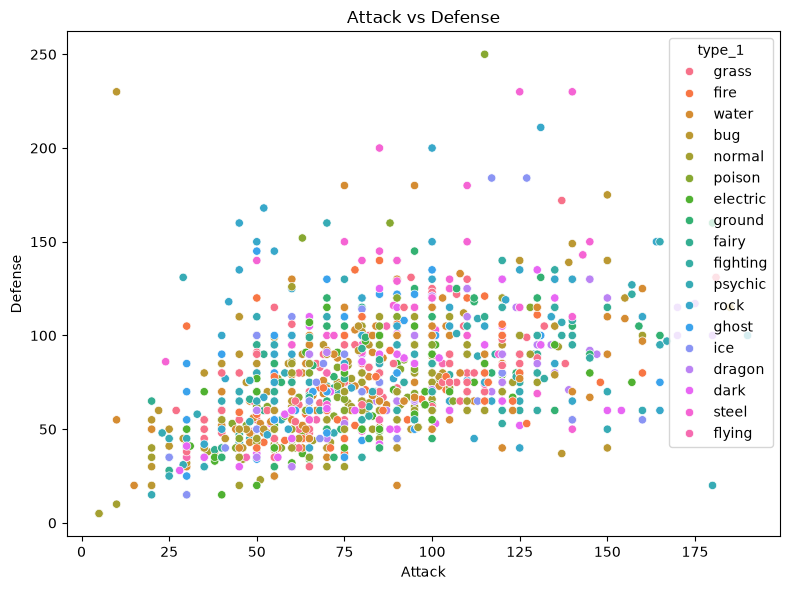

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='attack', y='defense', hue='type_1')
plt.title('Attack vs Defense')
plt.xlabel('Attack')
plt.ylabel('Defense')
plt.tight_layout()
plt.show()

Insight - Pokemon with higher attack often have higher defense.

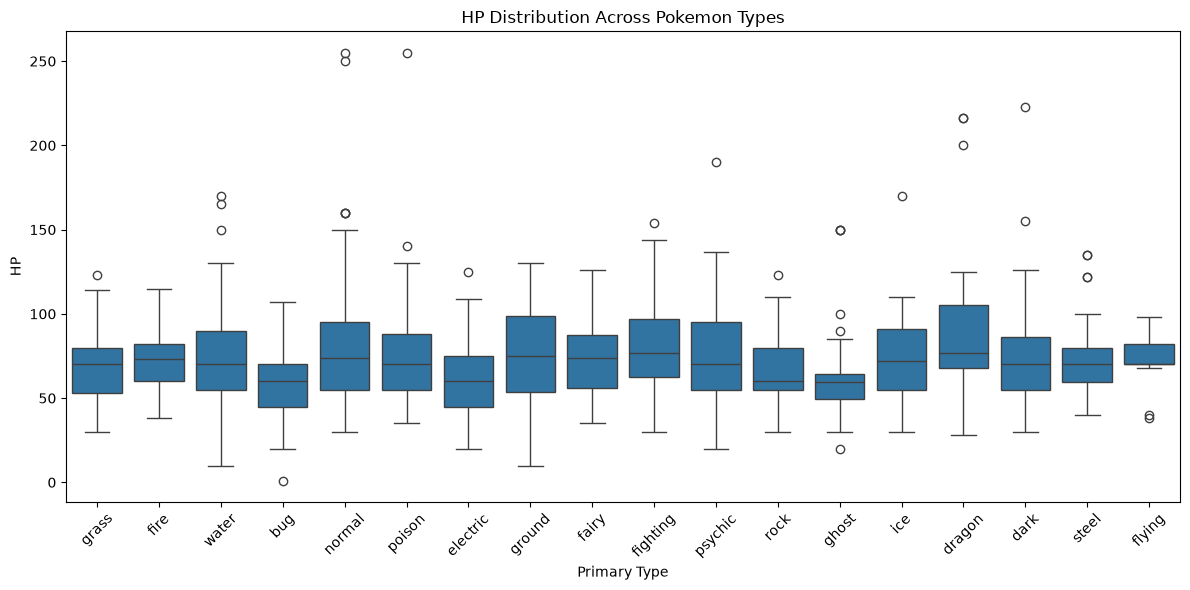

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='type_1', y='hp')
plt.title('HP Distribution Across Pokemon Types')
plt.xlabel('Primary Type')
plt.ylabel('HP')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

insight - Dragon, ground, and fighting Pokémon generally have higher HP values, while bug Pokemon tend to have lower HP

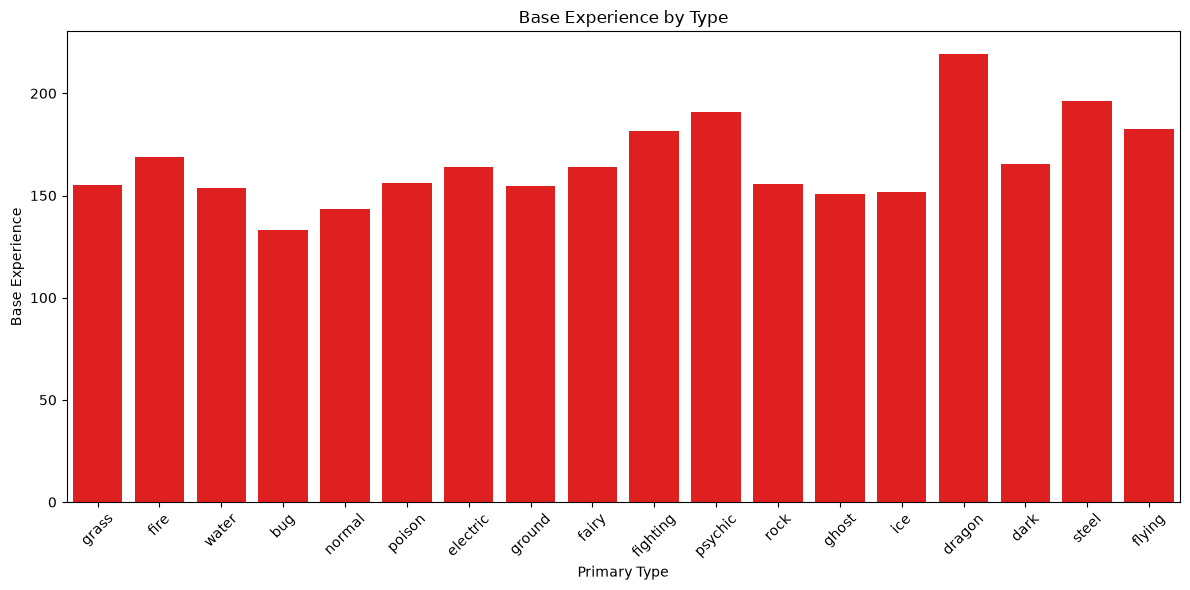

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='type_1', y='base_experience', estimator='mean', errorbar=None,color = 'red')
plt.title('Base Experience by Type')
plt.xlabel('Primary Type')
plt.ylabel('Base Experience')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

insight - Dragon Pokemon have the highest average base experience, while bug Pokemon have the lowest

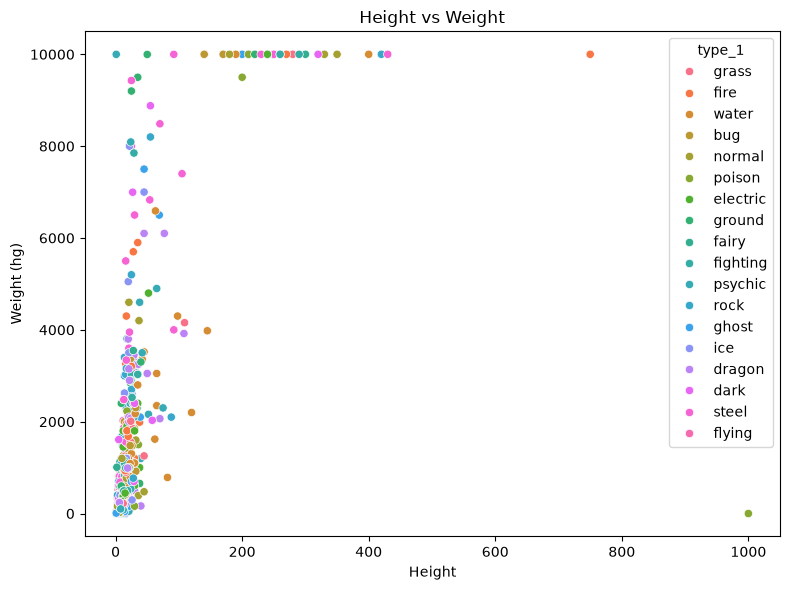

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='height_dm', y='weight_hg', hue='type_1')
plt.title('Height vs Weight')
plt.xlabel('Height')
plt.ylabel('Weight (hg)')
plt.tight_layout()
plt.show()

insight - Height and weight show a general positive relationship

## Analysis

1) Fighting type of pokemon tends to have the highest average attack

2) height and weight show a positive relationship, as height increases, weight generally increases.

3) Most useful features for distinguishing Pokémon types are Defense, HP,Weight,Height.Because these features show clear differences across type groups in the visualizations 

## Task 4 - Machine Learning Model

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, random_state=42))
])

lr_pipe.fit(X_train, Y_train)
y_pred_lr = lr_pipe.predict(X_test)

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, Y_train)

y_pred_dt = dt.predict(X_test)

In [22]:
print('Decision Tree Accuracy:', accuracy_score(Y_test, y_pred_dt))
print(classification_report(Y_test, y_pred_dt))

Decision Tree Accuracy: 0.2177121771217712
              precision    recall  f1-score   support

         bug       0.19      0.26      0.22        19
        dark       0.23      0.23      0.23        13
      dragon       0.18      0.17      0.17        12
    electric       0.40      0.50      0.44        20
       fairy       0.00      0.00      0.00         7
    fighting       0.27      0.25      0.26        12
        fire       0.04      0.06      0.05        17
      flying       0.00      0.00      0.00         3
       ghost       0.50      0.30      0.38        10
       grass       0.22      0.16      0.19        25
      ground       0.14      0.10      0.12        10
         ice       0.00      0.00      0.00         9
      normal       0.24      0.25      0.25        28
      poison       0.10      0.10      0.10        10
     psychic       0.33      0.24      0.28        17
        rock       0.29      0.29      0.29        17
       steel       0.25      0.30     

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, Y_train)

y_pred_rf = rf.predict(X_test)

In [32]:
print('Random forest Accuracy:', accuracy_score(Y_test, y_pred_rf))
print(classification_report(Y_test, y_pred_rf))

Random forest Accuracy: 0.3173431734317343
              precision    recall  f1-score   support

         bug       0.37      0.37      0.37        19
        dark       0.40      0.31      0.35        13
      dragon       0.36      0.33      0.35        12
    electric       0.47      0.45      0.46        20
       fairy       0.33      0.43      0.38         7
    fighting       0.30      0.25      0.27        12
        fire       0.19      0.29      0.23        17
      flying       0.00      0.00      0.00         3
       ghost       0.22      0.20      0.21        10
       grass       0.33      0.32      0.33        25
      ground       0.67      0.20      0.31        10
         ice       0.30      0.33      0.32         9
      normal       0.44      0.39      0.42        28
      poison       0.17      0.20      0.18        10
     psychic       0.25      0.29      0.27        17
        rock       0.38      0.47      0.42        17
       steel       0.37      0.70     

In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

rf_tuned = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_tuned,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)

best_rf = grid_search.best_estimator_

y_pred_tuned_rf = best_rf.predict(X_test)

In [37]:
print('Best Random Forest Parameters:', grid_search.best_params_)
print('Tuned Random Forest Accuracy:', accuracy_score(Y_test, y_pred_tuned_rf))
print('Precision:', precision_score(Y_test, y_pred_tuned_rf, average='macro', zero_division=0))
print('Recall:', recall_score(Y_test, y_pred_tuned_rf, average='macro', zero_division=0))
print('F1 Score:', f1_score(Y_test, y_pred_tuned_rf, average='macro', zero_division=0))
print(classification_report(Y_test, y_pred_tuned_rf))

Best Random Forest Parameters: {'class_weight': None, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Tuned Random Forest Accuracy: 0.2952029520295203
Precision: 0.30367808998761375
Recall: 0.252131023574522
F1 Score: 0.26067995446202374
              precision    recall  f1-score   support

         bug       0.22      0.32      0.26        19
        dark       0.43      0.23      0.30        13
      dragon       0.36      0.33      0.35        12
    electric       0.44      0.35      0.39        20
       fairy       0.33      0.14      0.20         7
    fighting       0.43      0.25      0.32        12
        fire       0.23      0.29      0.26        17
      flying       0.00      0.00      0.00         3
       ghost       0.25      0.20      0.22        10
       grass       0.27      0.28      0.27        25
      ground       0.50      0.10      0.17        10
         ice       0.00      0.00      0.00         9
      normal       0.3

In [38]:
results = [
    {
        'Model': 'Logistic Regression',
        'Accuracy': accuracy_score(Y_test, y_pred_lr),
        'Precision': precision_score(Y_test, y_pred_lr, average='macro', zero_division=0),
        'Recall': recall_score(Y_test, y_pred_lr, average='macro', zero_division=0),
        'F1 Score': f1_score(Y_test, y_pred_lr, average='macro', zero_division=0)
    },
    {
        'Model': 'Decision Tree',
        'Accuracy': accuracy_score(Y_test, y_pred_dt),
        'Precision': precision_score(Y_test, y_pred_dt, average='macro', zero_division=0),
        'Recall': recall_score(Y_test, y_pred_dt, average='macro', zero_division=0),
        'F1 Score': f1_score(Y_test, y_pred_dt, average='macro', zero_division=0)
    },
    {
        'Model': 'Random Forest',
        'Accuracy': accuracy_score(Y_test, y_pred_rf),
        'Precision': precision_score(Y_test, y_pred_rf, average='macro', zero_division=0),
        'Recall': recall_score(Y_test, y_pred_rf, average='macro', zero_division=0),
        'F1 Score': f1_score(Y_test, y_pred_rf, average='macro', zero_division=0)
    },
    {
        'Model': 'Tuned Random Forest',
        'Accuracy': accuracy_score(Y_test, y_pred_tuned_rf),
        'Precision': precision_score(Y_test, y_pred_tuned_rf, average='macro', zero_division=0),
        'Recall': recall_score(Y_test, y_pred_tuned_rf, average='macro', zero_division=0),
        'F1 Score': f1_score(Y_test, y_pred_tuned_rf, average='macro', zero_division=0)
    }
]

comparison_table = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
print(comparison_table.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1 Score
      Random Forest  0.317343   0.316445 0.313155  0.302697
Tuned Random Forest  0.295203   0.303678 0.252131  0.260680
      Decision Tree  0.217712   0.202577 0.190421  0.193263
Logistic Regression  0.184502   0.203805 0.146792  0.143602


Random Forest achieved the highest performance among the evaluated models, with an accuracy of 31.73% and an F1-score of 30.27%. The Tuned Random Forest achieved an accuracy of 29.52% and an F1-score of 26.07%.


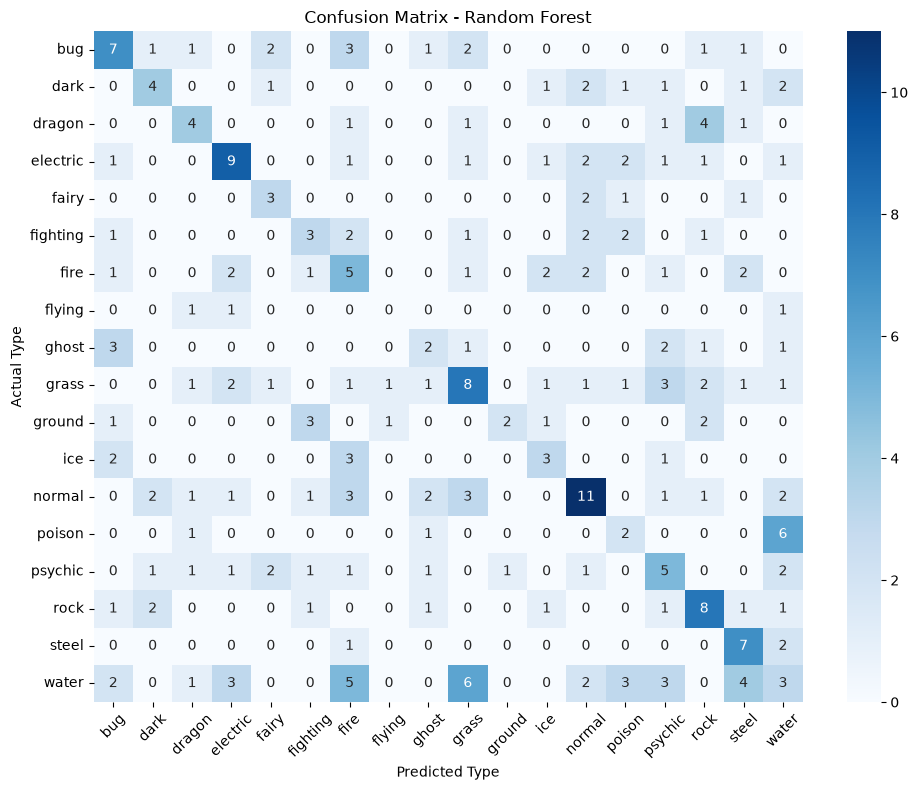

In [40]:
from sklearn.metrics import confusion_matrix
final_model = rf
final_predictions = y_pred_rf
labels = sorted(Y_test.unique())
cm = confusion_matrix( Y_test,final_predictions,labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm,annot=True,  fmt='d',cmap='Blues',xticklabels=labels,yticklabels=labels)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Type')
plt.ylabel('Actual Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
final_model = rf

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('\nTop 10 Most Influential Features:')
print(feature_importance.head(10).to_string(index=False))


Top 10 Most Influential Features:
        Feature  Importance
      weight_hg    0.153060
base_experience    0.146305
         attack    0.140286
        defense    0.137208
             hp    0.135758
      height_dm    0.120209
  type_2_flying    0.018131
   type_2_steel    0.013864
  type_2_dragon    0.013167
   type_2_water    0.012513


## Analysis

1) Random Forest achieved the best performance, with 31.73% accuracy and 30.27% macro F1-score.
2) Water, normal, grass, fire, and fighting had several misclassifications.
3) Overlapping feature values and fewer samples in some classes make certain Pokemon types harder to predict.

In [44]:
import os
import pickle

os.makedirs("models", exist_ok=True)

with open("models/pokemon_model.pkl", "wb") as file:
    pickle.dump({
        "model": rf,
        "features": X_train.columns.tolist(),
        "target": "type_1",
        "classes": sorted(Y_train.unique().tolist())
    }, file)

print("Saved models/pokemon_model.pkl")

Saved models/pokemon_model.pkl


## Analysis

1).It can help developers estimate a Pokemon’s likely type from its base statistics during game design.It can help players understand Pokemon statistics and support team-building or strategy decisions.

2).The predictions are estimates because the model uses only six statistics and does not consider moves, abilities, appearance, or secondary type.Prediction accuracy may be limited because some Pokemon types have similar statistics.
